# Processed sweep — read & plot per-analysis `<name>.h5` files

`process.py reduce` writes one `<analysis>.h5` per registered analysis at the
sweep root (or any directory you point it at). `ProcessedSweep` opens that
directory and discovers every `<name>.h5` whose `@analysis` root attr matches
its filename stem.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Make `analysis` importable when running from python/.
sys.path.insert(0, str(Path.cwd()))
from analysis.processed import ProcessedSweep

%matplotlib inline
plt.rcParams.update({"figure.dpi": 300})

## 1. Load the file

In [2]:
# Point at the directory that holds <analysis>.h5 files.
# (Pass a single .h5 file instead if you only want one analysis.)
PROCESSED_DIR = Path("..") / "output"
ps = ProcessedSweep(PROCESSED_DIR)
print(ps)
print("loop vars :", ps.loop_vars)
print("grid shape:", ps.grid_shape)
print("seeds     :", ps.seeds)
print("analyses  :", ps.analyses)
print("sweep_dir :", ps.attrs.get("sweep_dir"))
print("used / missing trajectories:",
      ps.attrs.get("n_trajectories_used"), "/",
      ps.attrs.get("n_trajectories_missing"))

ProcessedSweep('output', loop_vars=['Pe', 'De'], grid_shape=(20, 20), analyses=['force_orientation', 'msd'])
loop vars : ['Pe', 'De']
grid shape: (20, 20)
seeds     : [ 1  2  3  4  5  6  7  8  9 10]
analyses  : ['force_orientation', 'msd']
sweep_dir : /data/biophys/treado/GPUParticles/psweep_2026-05-10_N5000_R5_phase_diagram
used / missing trajectories: 4000 / 0


In [3]:
# Pull the two sweep axes by name (works for any 2-D sweep).
axis0_name, axis1_name = ps.loop_vars
axis0 = ps.axes[axis0_name]
axis1 = ps.axes[axis1_name]
print(f"{axis0_name}: {axis0.size} values, range [{axis0.min():.3g}, {axis0.max():.3g}]")
print(f"{axis1_name}: {axis1.size} values, range [{axis1.min():.3g}, {axis1.max():.3g}]")

Pe: 20 values, range [1, 500]
De: 20 values, range [0.001, 10]


## 2. Mean-squared displacement

`/msd/msd/mean` has shape `(Pe, De, frame)`; `/msd/lag_time/mean`
carries the lag axis. We plot MSD vs lag at a fixed slice of one axis,
fanning the other across colours.

In [4]:
msd_mean = ps.get("msd", "msd", kind="mean")            # (Pe, De, T)
msd_sem  = ps.get("msd", "msd", kind="sem")             # (Pe, De, T)
lag      = ps.get("msd", "lag_time", kind="mean")       # (Pe, De, T)
print("msd shape :", msd_mean.shape, "  axes:", ps.axis_order("msd", "msd"))
print("lag shape :", lag.shape)

msd shape : (20, 20, 51)   axes: ['Pe', 'De', 'seed', 'axis_0']
lag shape : (20, 20, 51)


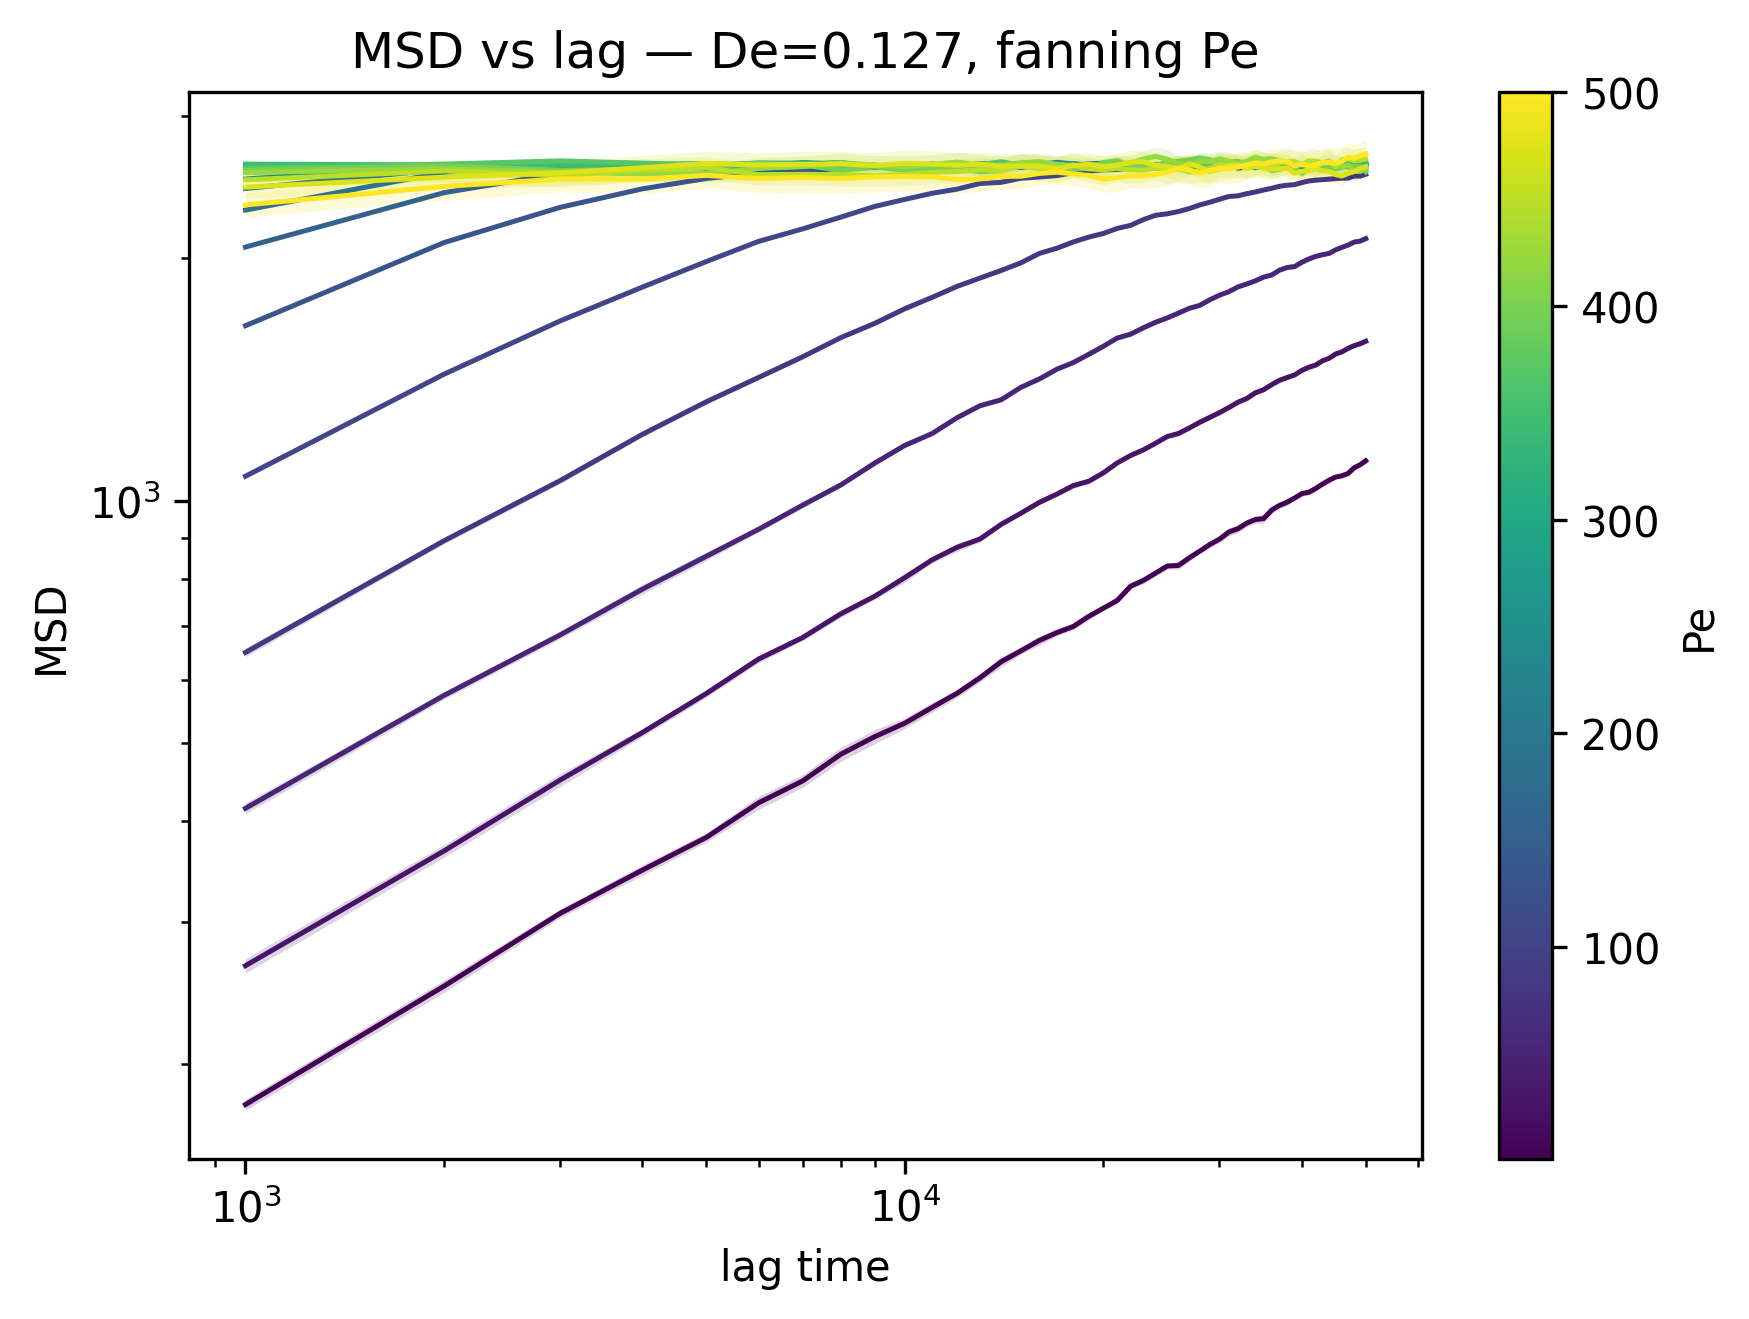

In [5]:
# MSD vs lag, fanning Pe at a fixed De (mid-axis).
j_fixed = axis1.size // 2
fig, ax = plt.subplots(figsize=(6.0, 4.5))
cmap = plt.get_cmap("viridis")
for i, val in enumerate(axis0):
    t = lag[i, j_fixed]
    y = msd_mean[i, j_fixed]
    e = msd_sem[i, j_fixed]
    sel = t > 0
    color = cmap(i / max(1, axis0.size - 1))
    ax.plot(t[sel], y[sel], color=color, lw=1.2)
    ax.fill_between(t[sel], (y - e)[sel], (y + e)[sel],
                    color=color, alpha=0.18, linewidth=0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("lag time")
ax.set_ylabel("MSD")
ax.set_title(f"MSD vs lag — {axis1_name}={axis1[j_fixed]:.3g}, fanning {axis0_name}")
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=axis0.min(), vmax=axis0.max()))
fig.colorbar(sm, ax=ax, label=axis0_name)
plt.tight_layout()
plt.show()

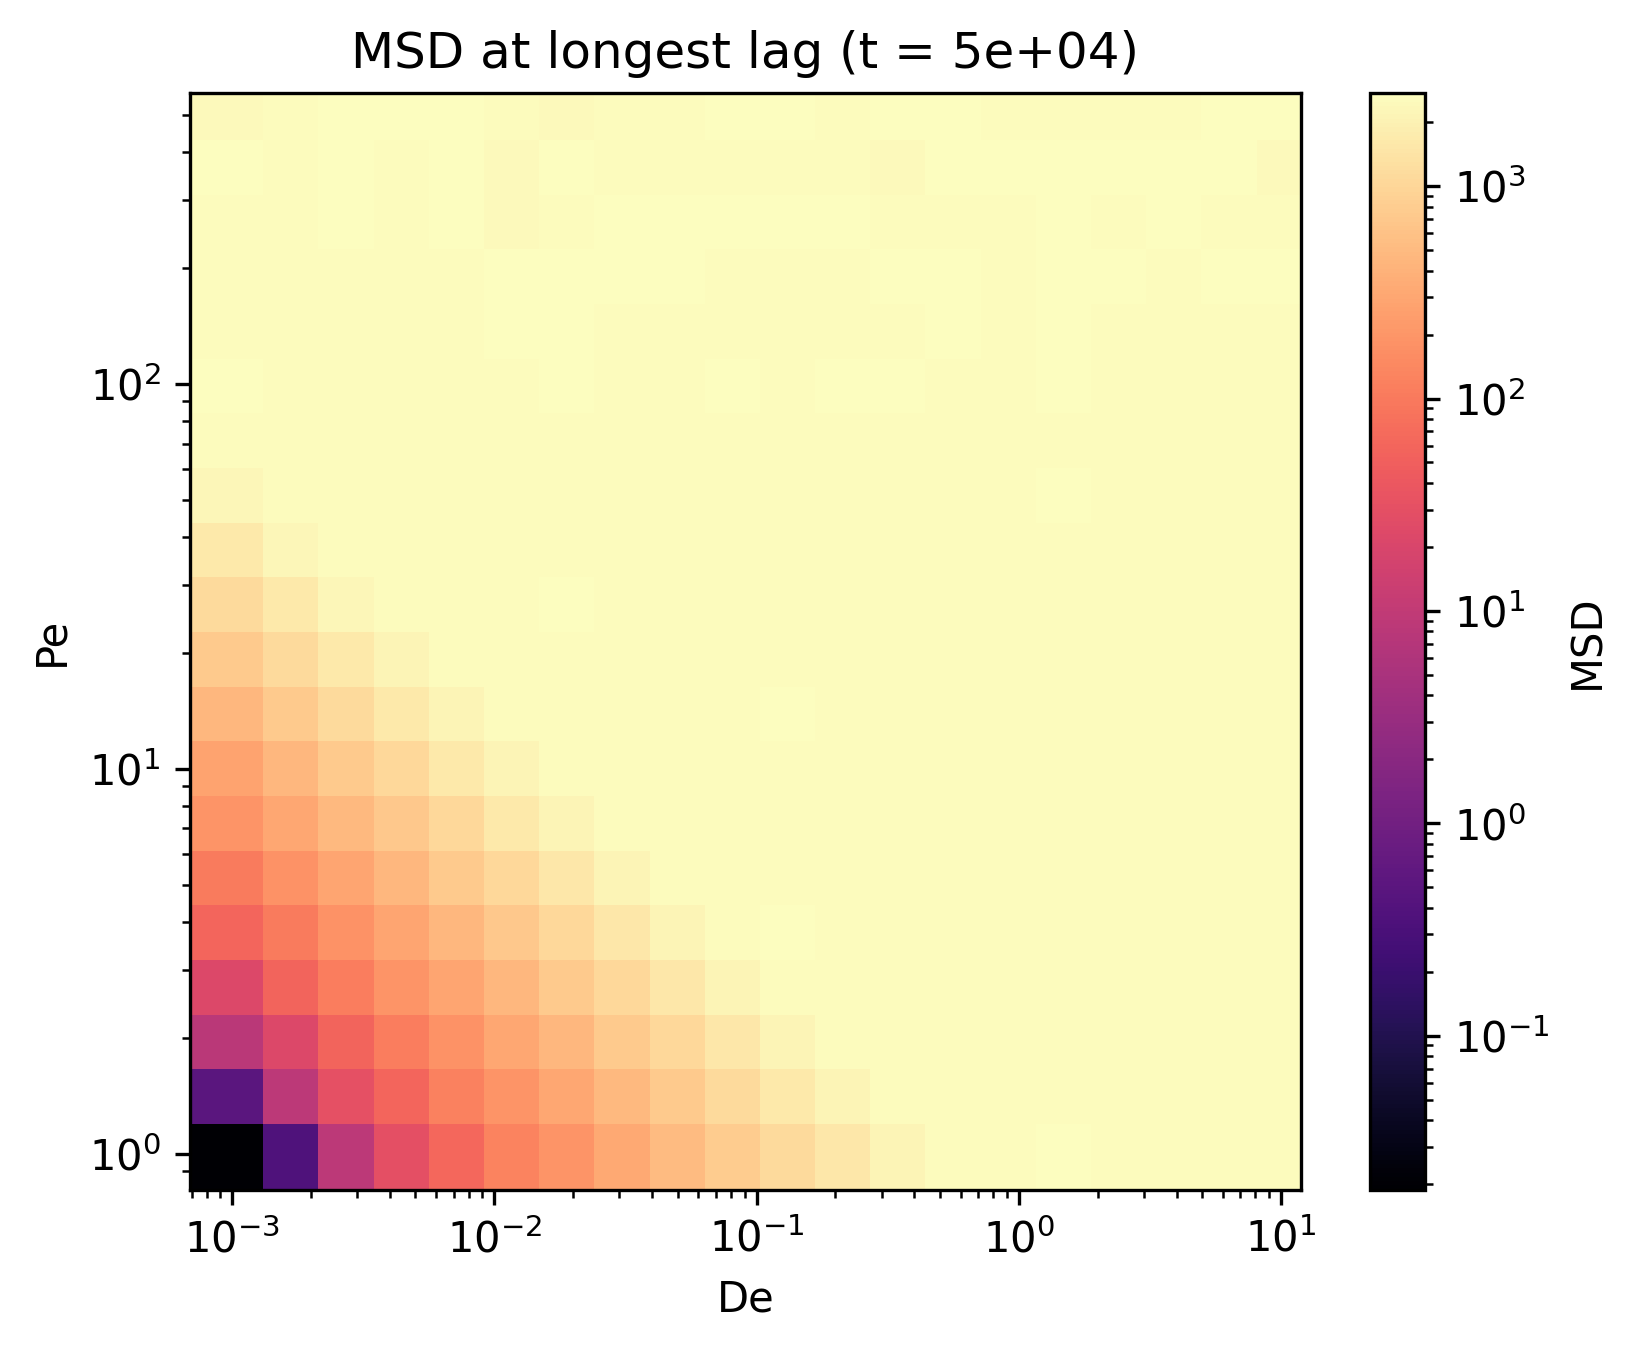

In [6]:
# Phase-diagram heatmap: MSD at the longest finite lag, log-scaled.
msd_long = msd_mean[..., -1]                  # (Pe, De)
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.pcolormesh(axis1, axis0, msd_long,
                   norm=LogNorm(vmin=np.nanmin(msd_long[msd_long > 0]),
                                vmax=np.nanmax(msd_long)),
                   cmap="magma", shading="auto")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(axis1_name)
ax.set_ylabel(axis0_name)
ax.set_title(f"MSD at longest lag (t = {lag[0, 0, -1]:.3g})")
fig.colorbar(im, ax=ax, label="MSD")
plt.tight_layout()
plt.show()

## 3. Force–orientation alignment

`force_orientation` reports per-trajectory $s = \langle F_i \cdot \hat n_i \rangle$,
its time series, and the cross-correlation $C(\tau) = \langle F(t+\tau)\cdot \hat n(t)\rangle$.

In [7]:
s_mean = ps.get("force_orientation", "s_mean", kind="mean")   # (Pe, De)
s_sem  = ps.get("force_orientation", "s_mean", kind="sem")    # (Pe, De)
print("s_mean shape:", s_mean.shape,
      "  range:", float(np.nanmin(s_mean)), "to", float(np.nanmax(s_mean)))

s_mean shape: (20, 20)   range: -36.947067571224636 to 0.025166506752913577


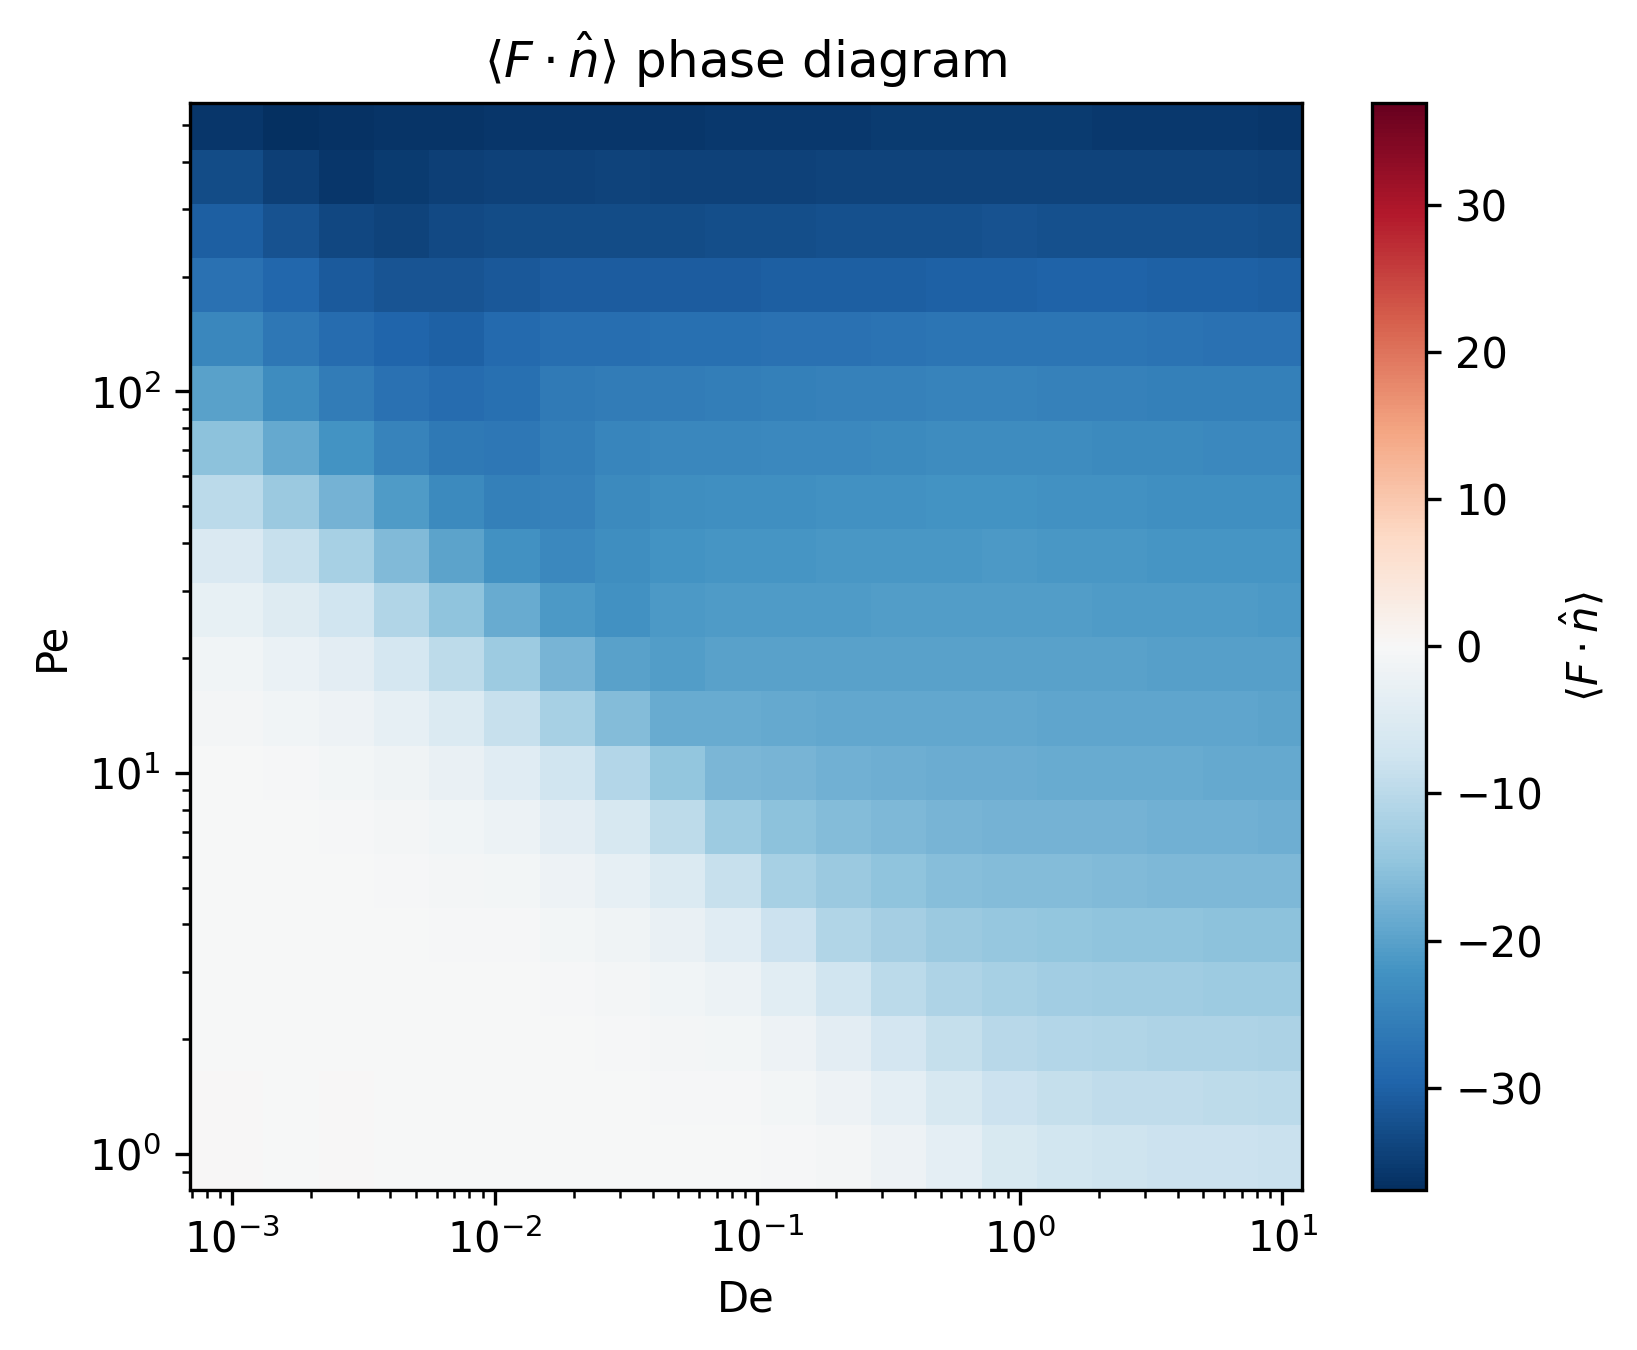

In [8]:
# Phase diagram of <F.n>.
vmax = float(np.nanmax(np.abs(s_mean)))
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.pcolormesh(axis1, axis0, s_mean,
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(axis1_name)
ax.set_ylabel(axis0_name)
ax.set_title(r"$\langle F \cdot \hat n \rangle$ phase diagram")
fig.colorbar(im, ax=ax, label=r"$\langle F \cdot \hat n \rangle$")
plt.tight_layout()
plt.show()

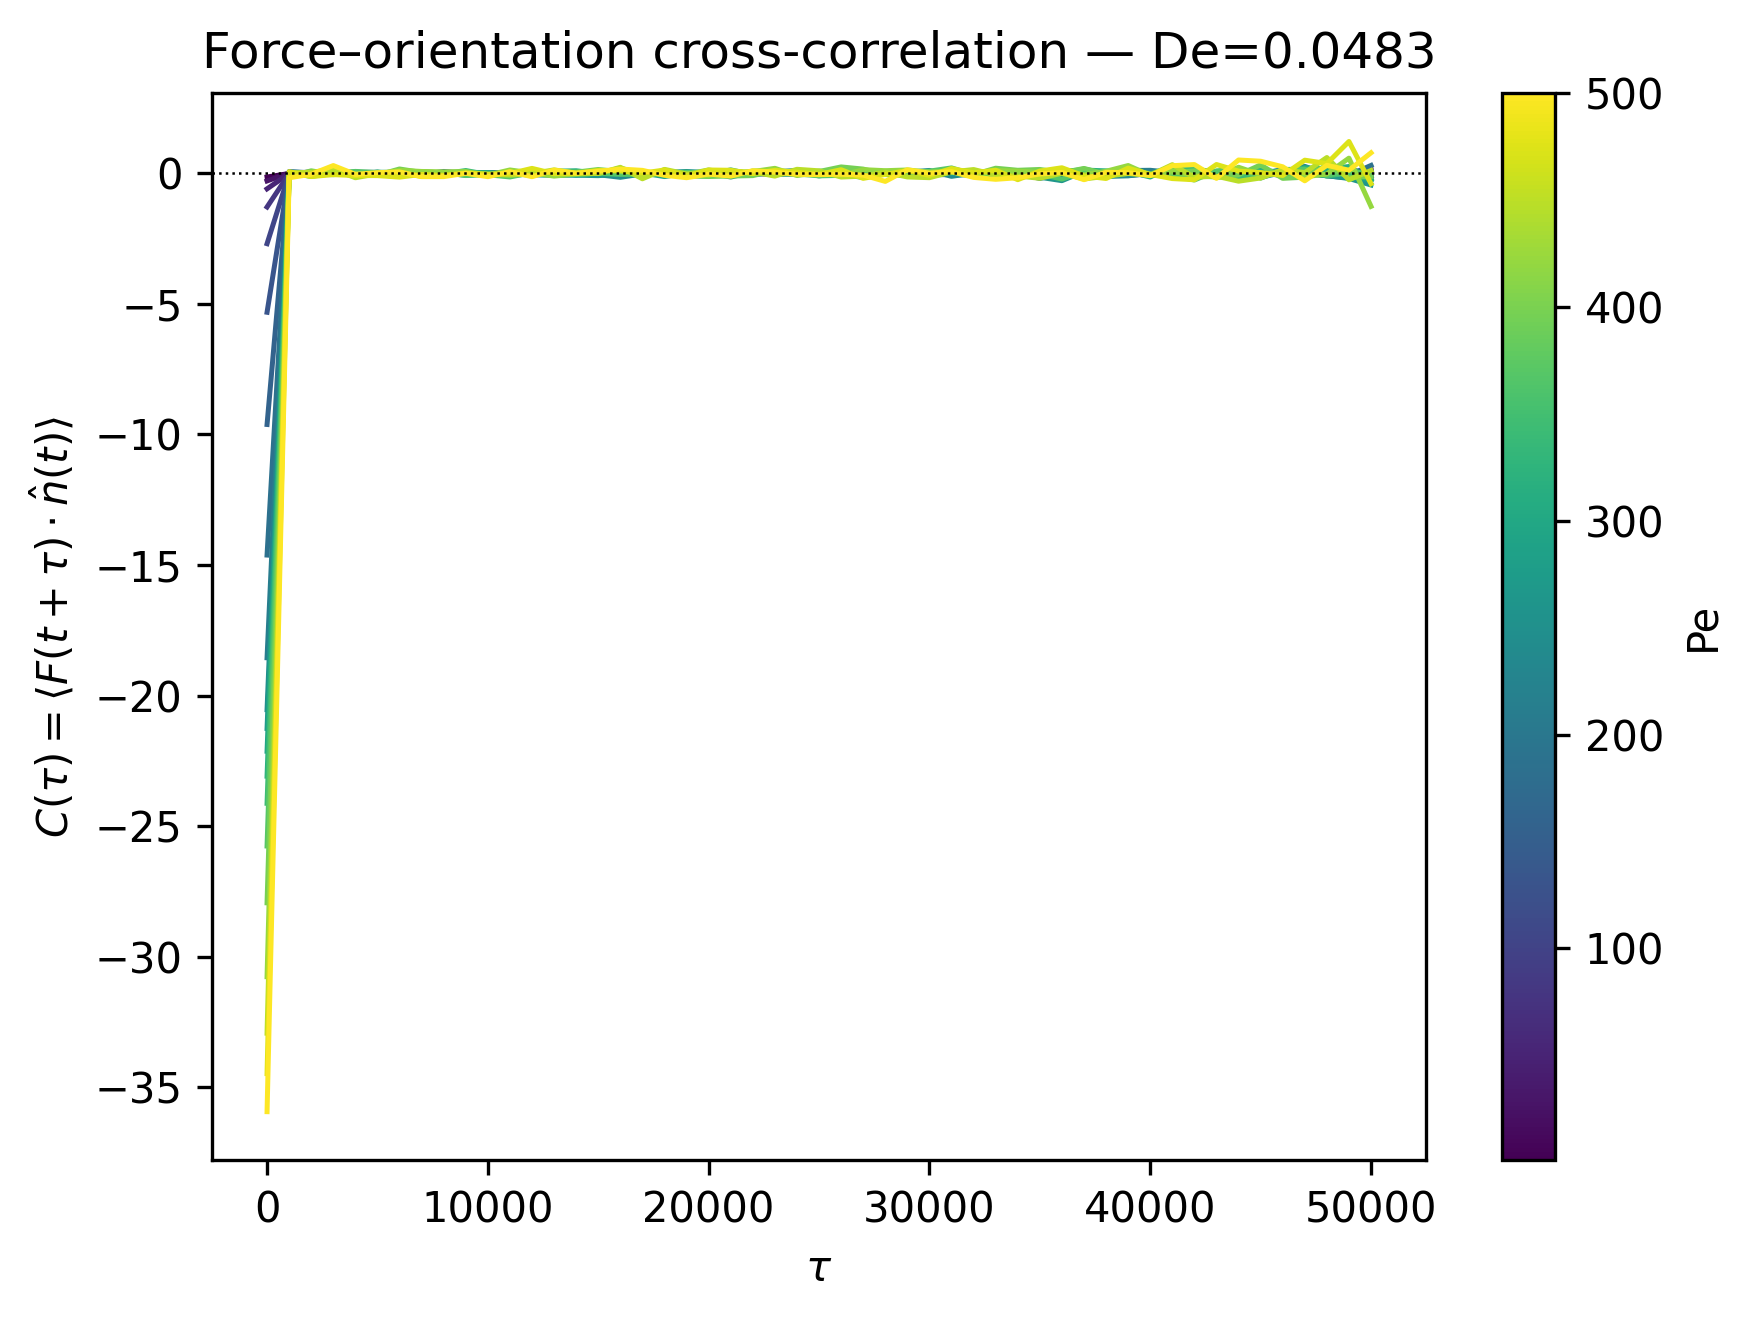

In [9]:
# C(tau) curves at fixed De, fanning Pe.
tau   = ps.get("force_orientation", "tau",   kind="mean")     # (Pe, De, lag)
C_tau = ps.get("force_orientation", "C_tau", kind="mean")     # (Pe, De, lag)
j_fixed = 8
fig, ax = plt.subplots(figsize=(6.0, 4.5))
cmap = plt.get_cmap("viridis")
for i in range(axis0.size):
    t = tau[i, j_fixed]
    c = C_tau[i, j_fixed]
    pos = t >= 0
    ax.plot(t[pos], c[pos],
            color=cmap(i / max(1, axis0.size - 1)), lw=1.2)
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$C(\tau) = \langle F(t+\tau)\cdot \hat n(t)\rangle$")
ax.set_title(f"Force–orientation cross-correlation — {axis1_name}={axis1[j_fixed]:.3g}")
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=axis0.min(), vmax=axis0.max()))
fig.colorbar(sm, ax=ax, label=axis0_name)
plt.tight_layout()
plt.show()

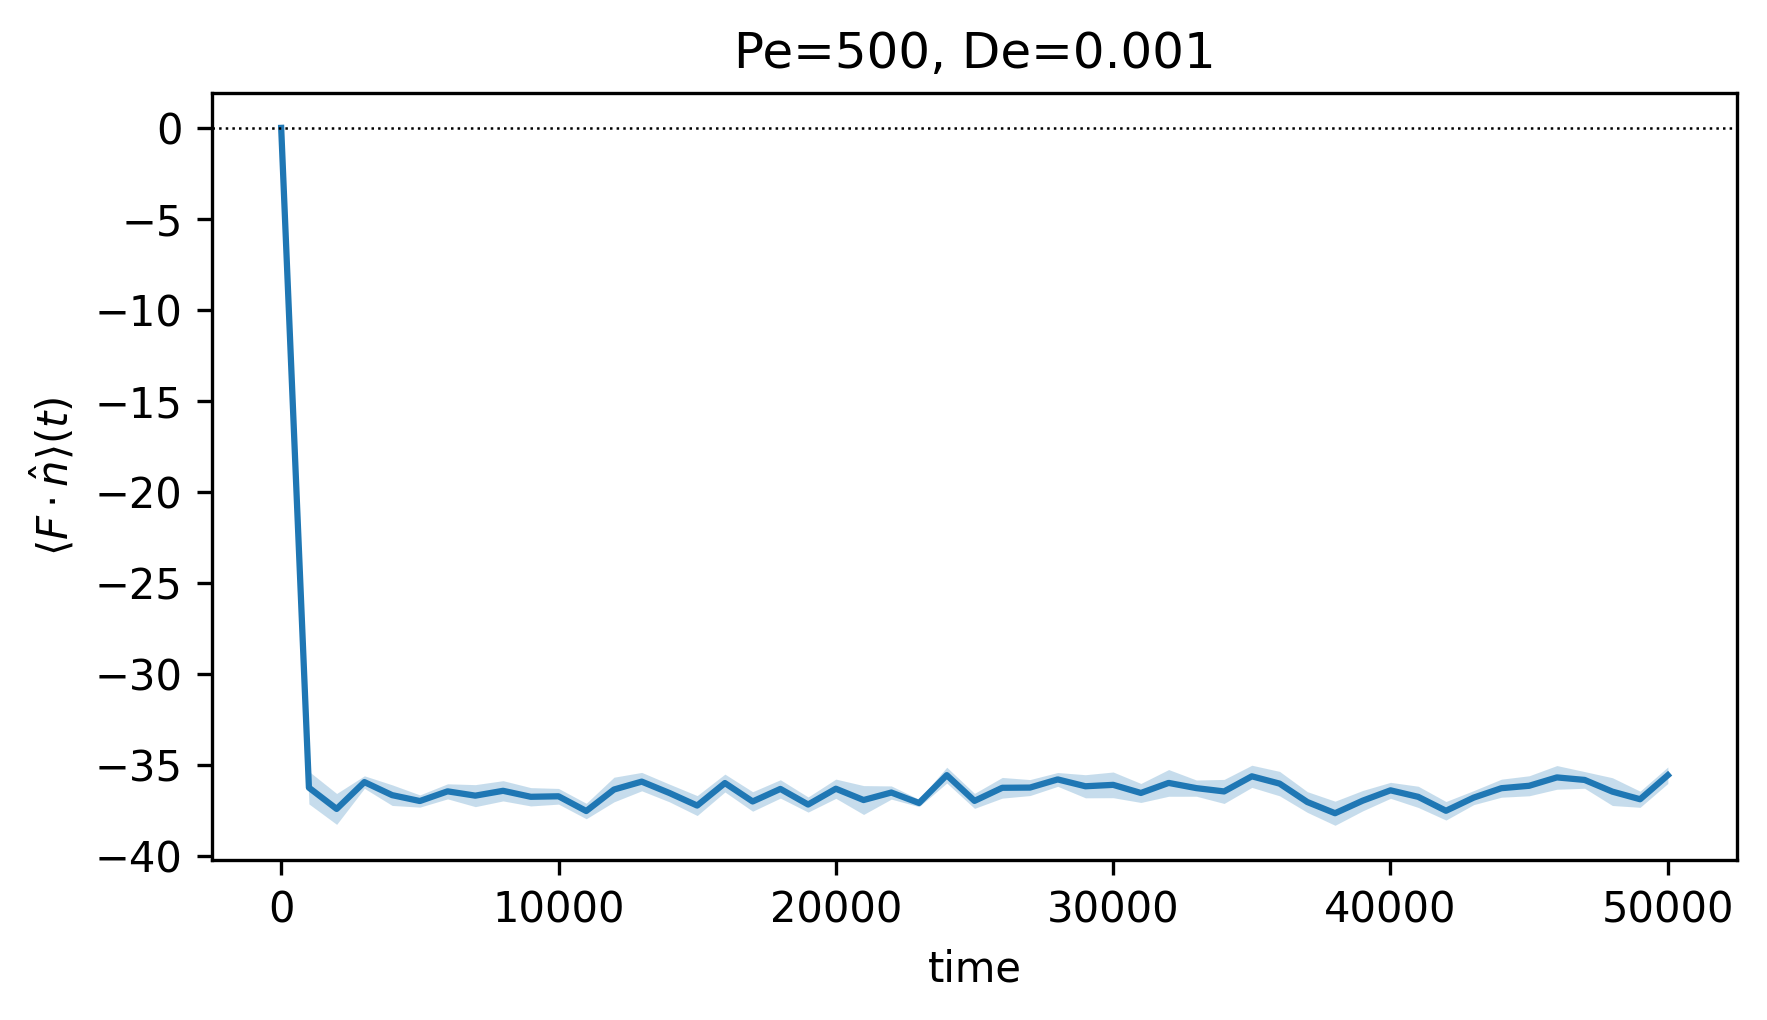

In [10]:
# Per-frame s(t) at the corner (most-active) point — sanity check.
i_corner = axis0.size - 1
j_corner = 0
times = ps.get("force_orientation", "times",     kind="mean")[i_corner, j_corner]
svt   = ps.get("force_orientation", "s_vs_time", kind="mean")[i_corner, j_corner]
svt_e = ps.get("force_orientation", "s_vs_time", kind="sem" )[i_corner, j_corner]
fig, ax = plt.subplots(figsize=(6.0, 3.5))
ax.plot(times, svt, color="C0")
ax.fill_between(times, svt - svt_e, svt + svt_e, color="C0", alpha=0.25, linewidth=0)
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("time")
ax.set_ylabel(r"$\langle F \cdot \hat n \rangle(t)$")
ax.set_title(f"{axis0_name}={axis0[i_corner]:.3g}, {axis1_name}={axis1[j_corner]:.3g}")
plt.tight_layout()
plt.show()

In [11]:
ps.close()